In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Kernel Basic Functions

In [30]:
class Kernel():
    
    def compute_norm_f(self, Kxx, alpha):
        '''
        Input: 
            Kxx: numpy array of shape (n, n)
            alpha: numpy array of shape (n)
        Output:
            norm_f: float
        '''
        
        norm_f = np.dot(alpha,Kxx @ alpha)
        
        return norm_f
    
    def compute_prediction_train(self, Kxx, alpha):
        '''
        Input: 
            Kxx: numpy array of shape (n, n)
            alpha: numpy array of shape (n)
        Output:
            y: numpy array of shape (n)
        '''
        
        y = Kxx @ alpha
        
        return y
    
    def compute_prediction_test(self, Kxz, alpha):
        '''
        Input: 
            Kxz: numpy array of shape (n, m)
            alpha: numpy array of shape (n)
        Output:
            y: numpy array of shape (m)
        '''
        
        y = Kxz.T @ alpha
        
        return y
    
    
class GaussianKernel(Kernel):
    
    def __init__(self, sigma = 1):
        self.sigma = sigma
    
    def get_Kxx(self, X):
        '''
        Input: 
            X: numpy array of shape (n, d)
        Output:
            Kxx: gnumpy array of shape (n, n)
        '''
        
        norm_X = np.sum(X**2, axis=1)
        dot = X @ X.T
        Kxx = np.exp(-0.5 * (norm_X[:, None] + norm_X[None, :] - 2 * dot) / self.sigma**2)
        
        return Kxx
    
    def get_Kxz(self, X, Z):
        '''
        Input: 
            X: numpy array of shape (n, d)
            Z: numpy array of shape (m, d)
        Output:
            Kxz: gnumpy array of shape (n, m)
        '''
        
        norm_X = np.sum(X**2, axis=1)
        norm_Z = np.sum(Z**2, axis=1)
        dot = X @ Z.T
        Kxz = np.exp(-0.5 * (norm_X[:, None] + norm_Z[None, :] - 2 * dot) / self.sigma**2)

        return Kxz
    
class LinearKernel(Kernel):
    
    def __init__(self):
        pass
    
    def get_Kxx(self, X):
        '''
        Input: 
            X: numpy array of shape (n, d)
        Output:
            Kxx: gnumpy array of shape (n, n)
        '''
        
        Kxx = np.dot(X,X.T)
        
        return Kxx
    
    def get_Kxz(self, X, Z):
        '''
        Input: 
            X: numpy array of shape (n, d)
            Z: numpy array of shape (m, d)
        Output:
            Kxz: gnumpy array of shape (n, m)
        '''
        
        Kxz = np.dot(X,Z.T) 
        
        return Kxz

In [31]:
def center_train_gram_matrix(Kxx):
    '''
    Input:
        Kxx: numpy array of shape (n, n)
    Output:
        Kxx_c: numpy array of shape (n, n)
    '''
    
    Kxx_c = Kxx - np.mean(Kxx, axis=0, keepdims=True) - np.mean(Kxx, axis=1, keepdims=True) + np.mean(Kxx, keepdims=True)
    
    return Kxx_c

def center_test_gram_matrix(Kxx, Kxz):
    '''
    Input:
        Kxx: numpy array of shape (n, n)
        Kxz: numpy array of shape (n, m)
    Output:
        K_c: numpy array of shape (n, m)
    '''
    
    Kxz_c = Kxz - np.mean(Kxz, axis=0, keepdims=True) - np.mean(Kxx, axis=1, keepdims=True) + np.mean(Kxx, keepdims=True)
    
    return Kxz_c

# I. Kernel Ridge Regression

Ridge Regression is the standard linear regression with an l2 regularization 

\begin{equation*}
\min_{w \in \mathbb{R}^d} \frac{1}{n}\sum_{i=1}^n (\langle w, x_i \rangle - y_i)^2 + \lambda ||w||_2^2
\end{equation*}

It is very natural to write a kernel version

\begin{equation*}
\min_{f \in \mathcal{H}} \frac{1}{n}\sum_{i=1}^n ( \langle f, \phi(x_i) \rangle_\mathcal{H}  - y_i)^2 + \lambda ||f||_\mathcal{H}^2
\end{equation*}

Note that using the reproducing property this is equivalent to

\begin{equation*}
\min_{f \in \mathcal{H}} \frac{1}{n}\sum_{i=1}^n ( f(x_i) \ - y_i)^2 + \lambda ||f||_\mathcal{H}^2
\end{equation*}

By the representer theorem, any minimizer has the form
\begin{equation*}
f(\cdot) = \sum_{i=1}^n \alpha_i \, k(x_i, \cdot), 
\qquad \alpha \in \mathbb{R}^n.
\end{equation*}

Let $K \in \mathbb{R}^{n \times n}$ be the kernel matrix with entries 
$K_{ij} = k(x_i, x_j)$, and define $y = (y_1, \ldots, y_n)^\top$.  
Then
\begin{equation*}
f(x_j) = \sum_{i=1}^n \alpha_i k(x_i, x_j) = (K\alpha)_j,
\qquad 
\|f\|_{\mathcal H}^2 = \alpha^\top K \alpha.
\end{equation*}

Hence the optimization problem becomes
\begin{equation*}
\min_{\alpha \in \mathbb{R}^n} \; 
\frac{1}{n} \, \|K\alpha - y\|_2^2 + \lambda \, \alpha^\top K \alpha.
\end{equation*}

> **Question 1:** 
>
> Solve the problem above and implement the Kernel Ridge Regression

#### Kernel Ridge Regression Closed-form Solution

We want to minimize:
$$
J(\alpha) = \frac{1}{n}\|K\alpha - y\|^2 + \lambda \alpha^\top K \alpha
$$

Compute gradient and set it to zero:
$$
\nabla_\alpha J = \frac{2}{n}K(K\alpha - y) + 2\lambda K\alpha = 0
$$

Simplify:
$$
K(K + n\lambda I)\alpha = Ky
$$

Assuming $K$ is invertible, then multiply both side of equation by $K^{-1}$, we have:
$$
I(K + n\lambda I)\alpha = Iy 
$$
$$
(K + n\lambda I)\alpha = y
$$

Since $K$ is invertible, then $(K + n\lambda I)$ is inversible. Then multiply both side of equation by $(K + n\lambda I)^{-1}$ . Hence the optimal solution is:
$$
\boxed{\alpha = (K + n\lambda I)^{-1} y}
$$


In [32]:
def get_alpha_KRR(Kxx: np.ndarray, y: np.ndarray, lbda: float) -> np.ndarray:
    '''
    Input:
        Kxx: numpy array of shape (n, n)
        y: numpy array of shape (n,)
        lbda: float (regularization strength λ)
    Output:
        alpha: numpy array of shape (n,)
    '''
    
    #TO-DO: implement the function
    # alpha = (Kxx + lbda*n*I)^(-1)y
    n = Kxx.shape[0]
    I = np.eye(n)
    alpha = np.linalg.inv(Kxx + lbda*n*I) @ y
    
    return alpha

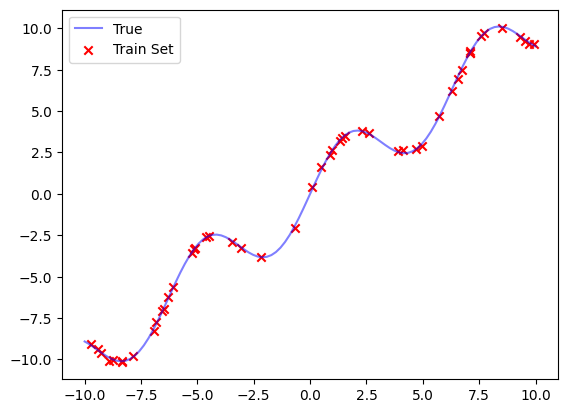

In [33]:
f = lambda x: 2*np.sin(x)+x

n  = 50
m = 100

X = np.random.uniform(-10, 10, n)
y = f(X) + np.random.normal(0, 0.1, n)
Z = np.linspace(-10, 10, m)

plt.figure()
plt.plot(Z, f(Z), color = 'blue', label = 'True', alpha = 0.5)
plt.scatter(X, y, color = 'red', label = 'Train Set', marker='x')
plt.legend()
plt.show()

X = X.reshape(-1, 1)
Z = Z.reshape(-1, 1)

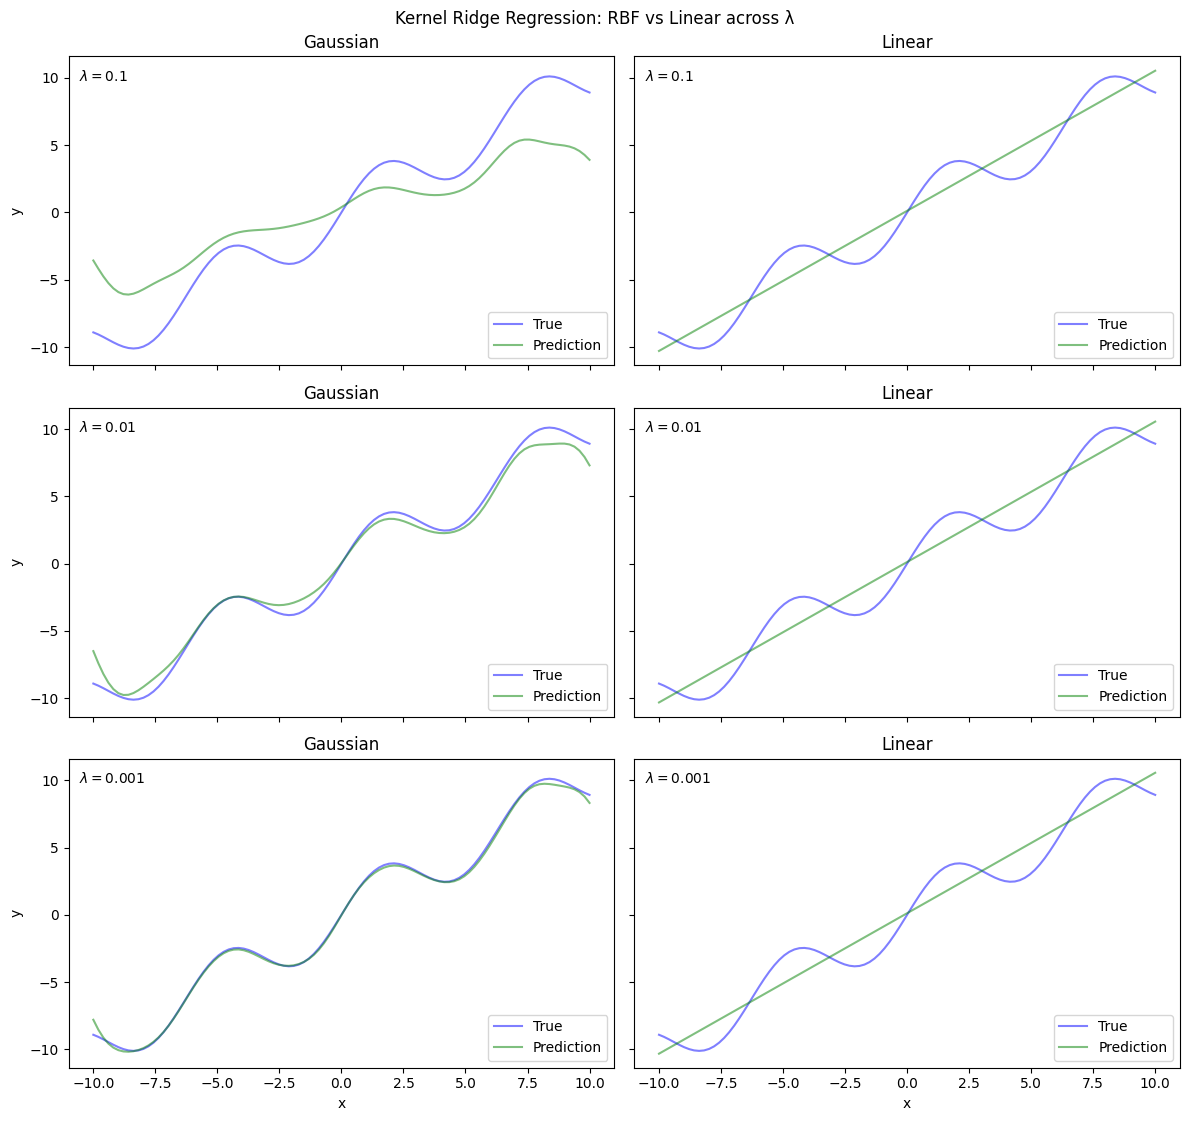

In [34]:
lambdas = [0.1, 0.01, 0.001]
sigma = 1.0  # for Gaussian (RBF) kernel


kernels = {
    'Gaussian': GaussianKernel(sigma=sigma),
    'Linear': LinearKernel(),
}


fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12), sharex=True, sharey=True)
fig.suptitle('Kernel Ridge Regression: RBF vs Linear across λ', y=0.93)

for col, (kname, kernel) in enumerate(kernels.items()):
    for row, lbda in enumerate(lambdas):
        ax = axes[row, col]

        # Compute Gram matrices
        Kxx = kernel.get_Kxx(X)
        Kxz = kernel.get_Kxz(X, Z)

        # Center in RKHS
        Kxx_c = center_train_gram_matrix(Kxx)
        Kxz_c = center_test_gram_matrix(Kxx, Kxz)

        # Replace with centered
        Kxx = Kxx_c
        Kxz = Kxz_c

        # Solve for alpha and predict
        alpha = get_alpha_KRR(Kxx, y, lbda)
        Y_pred = kernel.compute_prediction_test(Kxz, alpha)


        ax.plot(Z, f(Z), color='blue', label='True', alpha=0.5)
        ax.plot(Z, Y_pred, color='green', label='Prediction', alpha=0.5)

        if kname.startswith("RBF"):
            ax.set_title(f'{kname} (σ={sigma})')
        else:
            ax.set_title(f'{kname}')


        ax.text(0.02, 0.92, rf'$\lambda={lbda}$', transform=ax.transAxes)

        if col == 0:
            ax.set_ylabel('y')
        if row == len(lambdas) - 1:
            ax.set_xlabel('x')

        ax.legend(loc='best')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


> **Question 2:** 
>
> What is the effect of the regularization parameter $\lambda$?   What happens when you change $\sigma$ in the plots above?

---
If we observe the loss equation:
$$
J(\alpha) = \frac{1}{n}\|K\alpha - y\|^2 + \lambda \alpha^\top K \alpha
$$

The first term is control the data fitting, it try to minimize the error between the prediction and true. The second term  penalizes model complexity through $ \alpha^\top K \alpha $. As we increase $ \lambda $ the regularization term dominate the equation, and the coefficient $\alpha $ become smaller interm of magnitude and the predictor $f(x)$ is smoother and close to linear form. Then the model is underfit.

As $\lambda$ decrease, the regularization term is weekens. The model fix to the data more closely and the predictor can capture small oscillation. But the model is overfit, like the case $\lambda = 0.001$.

---
**Effect of the kernel width $ \sigma $:**

$$
k(x_i, x_j) = \exp \left(-\frac{|x_i - x_j|^2}{2\sigma^2}\right),
$$
the parameter $ \sigma $ controls how local each basis function is.

* **Large $ \sigma $** → kernel values decay slowly → smoother, more global influence → smoother fit (less flexible).
* **Small $ \sigma $** → kernel values decay quickly → each data point affects only its neighbors → very flexible fit (can overfit noise).

Thus, $ \sigma $ controls the **complexity of the hypothesis space**, while $ \lambda$ controls the **strength of regularization** inside that space. In our data I observe that $\lambda = 0.01$ and $\sigma = 2$ is the best one.

> **Question 3:** 
>
> Propose a numerical solver to this optimization problem instead of the closed form solution. Compare both approaches.

Since the closed-form solution of Kernel Ridge Regression is:
$$
\alpha^* = (K + n\lambda I)^{-1}y.
$$
Computing this explicitly requires **inverting an $ n \times n $ matrix**, which costs $(O(n^3))$ and can be numerically unstable for large (n). 

Thus, we can solve $\alpha$ numirically by using the optimization method like **Gradient Descent formulation** .

**Gradient Descent formulation**:

We minimize:

$$
J(\alpha) = \frac{1}{n}|K\alpha - y|^2 + \lambda \alpha^\top K \alpha.
$$

Its gradient is:

$$
\nabla_\alpha J = \frac{2}{n}K(K\alpha - y) + 2\lambda K\alpha.
$$

A simple iterative update is:

$$
\alpha^{(t+1)} = \alpha^{(t)} - \eta , \nabla_\alpha J(\alpha^{(t)}),
$$
where $ \eta > 0 $ is the learning rate.

In [35]:
def fit_alpha(
    Kxx: np.ndarray,
    y: np.ndarray,
    lbda: float,
    lr: float = 1e-2,
    epochs: int = 2000,
) -> tuple[np.ndarray, list[float]]:
    n = Kxx.shape[0]
    alpha = np.zeros(n, dtype=Kxx.dtype)
    history = []

    #To-do: alpha and history using gradient based method
    #history should contain the objective value at each epoch for plotting

    for epoch in range(epochs):
        # Compute the prediction
        f_x = Kxx @ alpha
        # Compute the error
        error = f_x - y
        # Compute the gradient
        grad = (2/n) * (Kxx @ error) + 2 *  lbda * alpha
        # Update alpha
        alpha -= lr * grad
        # Compute the objective value
        obj_value = (1/n) * np.dot(error, error) + lbda * np.dot(alpha, alpha)
        history.append(obj_value)
    
    return alpha, history


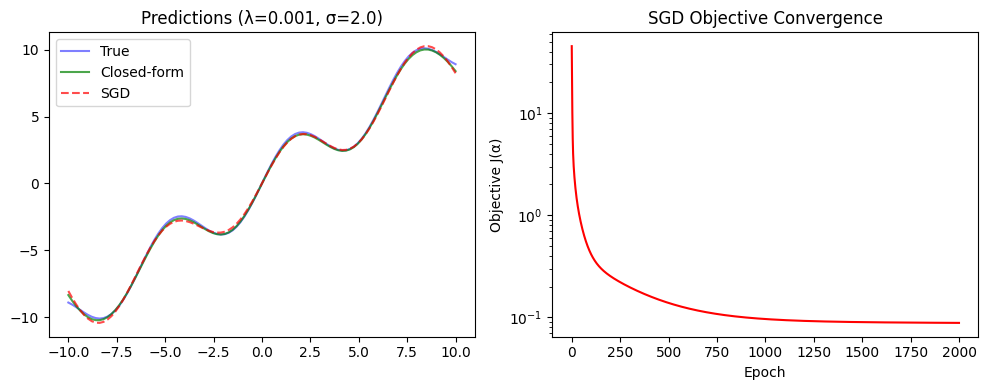

‖α_sgd - α_closed‖ = 1.997e+01


In [37]:
def compare_closed_vs_sgd(Kxx, Kxz, y, Z, kernel, lbda=1e-2):
    # Closed-form
    alpha_closed = get_alpha_KRR(Kxx, y, lbda)
    Y_pred_closed = kernel.compute_prediction_test(Kxz, alpha_closed)

    # SGD
    alpha_sgd, history = fit_alpha(Kxx, y, lbda, lr=5e-2, epochs=2000)
    Y_pred_sgd = kernel.compute_prediction_test(Kxz, alpha_sgd)


    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.title(f"Predictions (λ={lbda}, σ={kernel.sigma if hasattr(kernel, 'sigma') else 'N/A'})")
    plt.plot(Z, f(Z), color='blue', label='True', alpha=0.5)
    plt.plot(Z, Y_pred_closed, color='green', label='Closed-form', alpha=0.7)
    plt.plot(Z, Y_pred_sgd, color='red', linestyle='--', label='SGD', alpha=0.7)
    plt.legend()

    plt.subplot(1,2,2)
    plt.title("SGD Objective Convergence")
    plt.plot(history, color='red')
    plt.xlabel("Epoch")
    plt.ylabel("Objective J(α)")
    plt.yscale("log")

    plt.tight_layout()
    plt.show()

    diff = np.linalg.norm(alpha_sgd - alpha_closed)
    print(f"‖α_sgd - α_closed‖ = {diff:.3e}")

    return alpha_closed, alpha_sgd


# --- Hyperparameters ---
sigma = 2.0
lbda = 1e-3

# --- Build Gaussian kernel and Gram matrices ---
kernel = GaussianKernel(sigma=sigma)
Kxx = kernel.get_Kxx(X)        # (n x n)
Kxz = kernel.get_Kxz(X, Z)     # (n x m)

# --- Center in RKHS (train then test) ---
Kxx_c = center_train_gram_matrix(Kxx)
Kxz_c = center_test_gram_matrix(Kxx, Kxz)

# --- Compare closed-form vs SGD (uses your get_alpha_KRR) ---
alpha_closed, alpha_sgd = compare_closed_vs_sgd(
    Kxx=Kxx_c,
    Kxz=Kxz_c,
    y=y,
    Z=Z,
    kernel=kernel,
    lbda=lbda
)



By observing the result both approach is very close. They almost identical and really clost too the true.

> **Question 4:** 
>
> For a fixed $\lambda$, plot the MSE error varying the size $n$ of training points. Also, for a fixed $n$, plot the test error vs $1/\lambda$.  Interpret the results


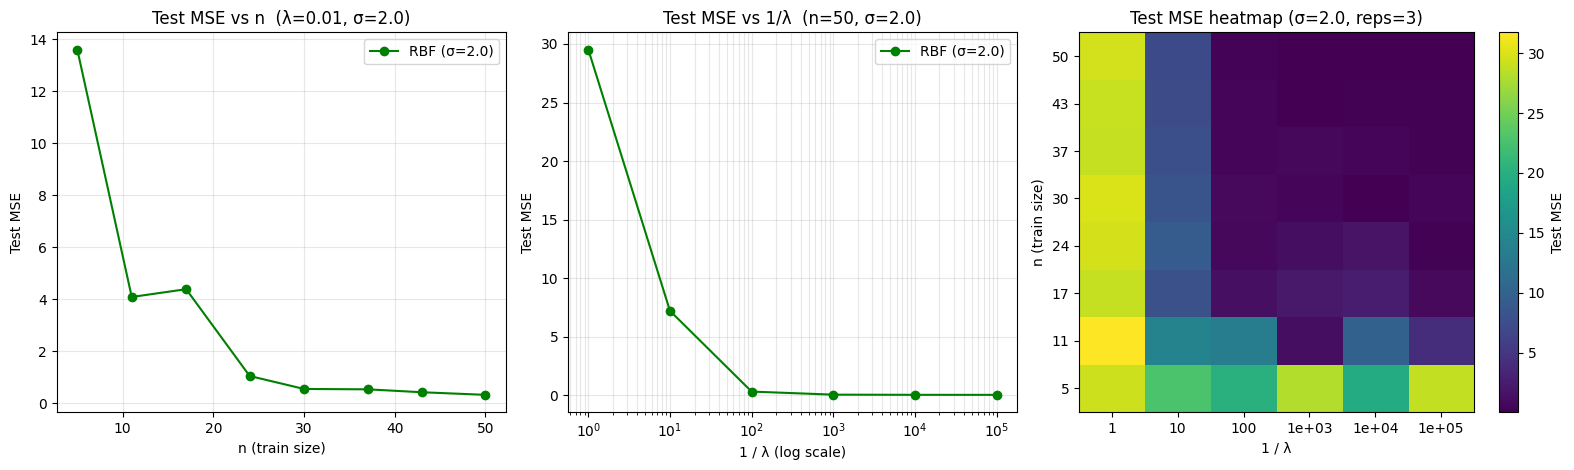

In [24]:
lambdas = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
sigma = 2.0                
lambda_fixed = 0.01       
reps = 3                   
kernel = GaussianKernel(sigma=sigma)

y_true_Z = f(Z).reshape(-1)

def krr_test_mse(X_tr, y_tr, Z, y_true_Z, kernel, lbda):
    """Train KRR on (X_tr, y_tr); return MSE on separate test grid Z with y_true_Z=f(Z)."""
    Kxx = kernel.get_Kxx(X_tr)
    Kxz = kernel.get_Kxz(X_tr, Z)
    # Center in RKHS
    Kxx_c = center_train_gram_matrix(Kxx)
    Kxz_c = center_test_gram_matrix(Kxx, Kxz)
    # Fit + predict
    alpha = get_alpha_KRR(Kxx_c, y_tr, lbda)
    y_pred = kernel.compute_prediction_test(Kxz_c, alpha).reshape(-1)
    return float(np.mean((y_true_Z - y_pred) ** 2))

# -----------------------------
# 1) Test MSE vs n (λ fixed)
# -----------------------------
rng = np.random.default_rng(0)
n_max = len(X)
ns = np.unique(np.linspace(max(5, n_max // 10), n_max, 8, dtype=int))

mses_vs_n = []
for n_tr in ns:
    fold_mses = []
    for _ in range(reps):
        idx = rng.choice(n_max, size=n_tr, replace=False)
        X_tr = X[idx]; y_tr = y[idx]
        fold_mses.append(krr_test_mse(X_tr, y_tr, Z, y_true_Z, kernel, lambda_fixed))
    mses_vs_n.append(np.mean(fold_mses))

# -----------------------------
# 2) Test MSE vs 1/λ (n fixed)
# -----------------------------
n_fixed = n_max  
X_tr_fixed = X[:n_fixed]
y_tr_fixed = y[:n_fixed]

inv_lambdas = np.array([1.0 / lb for lb in lambdas])
mses_vs_lambda = np.array([
    krr_test_mse(X_tr_fixed, y_tr_fixed, Z, y_true_Z, kernel, lb)
    for lb in lambdas
])

order = np.argsort(inv_lambdas)
inv_lambdas_sorted = inv_lambdas[order]
mses_vs_lambda_sorted = mses_vs_lambda[order]

# -----------------------------
# 3) Test MSE heatmap over (n, 1/λ)
# -----------------------------
lambdas_plot = np.array(lambdas)[order]
inv_lambdas_plot = inv_lambdas_sorted

errors_test = np.zeros((len(ns), len(lambdas_plot)), dtype=float)
for i, n_tr in enumerate(ns):
    for j, lb in enumerate(lambdas_plot):
        fold_mses = []
        for _ in range(reps):
            idx = rng.choice(n_max, size=n_tr, replace=False)
            X_tr = X[idx]; y_tr = y[idx]
            fold_mses.append(krr_test_mse(X_tr, y_tr, Z, y_true_Z, kernel, lb))
        errors_test[i, j] = np.mean(fold_mses)



#Plots
fig = plt.figure(figsize=(16, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.1])
ax_n   = fig.add_subplot(gs[0, 0])
ax_lmb = fig.add_subplot(gs[0, 1])
ax_hm  = fig.add_subplot(gs[0, 2])

ax_n.plot(ns, mses_vs_n, marker='o', color='green', label=f'RBF (σ={sigma})')
ax_n.set_title(f"Test MSE vs n  (λ={lambda_fixed}, σ={sigma})")
ax_n.set_xlabel("n (train size)")
ax_n.set_ylabel("Test MSE")
ax_n.grid(True, alpha=0.3)
ax_n.legend()


ax_lmb.plot(inv_lambdas_sorted, mses_vs_lambda_sorted, marker='o', color='green', label=f'RBF (σ={sigma})')
ax_lmb.set_xscale('log')
ax_lmb.set_title(f"Test MSE vs 1/λ  (n={n_fixed}, σ={sigma})")
ax_lmb.set_xlabel("1 / λ (log scale)")
ax_lmb.set_ylabel("Test MSE")
ax_lmb.grid(True, which='both', alpha=0.3)
ax_lmb.legend()

im = ax_hm.imshow(errors_test, aspect='auto', origin='lower')
ax_hm.set_title(f"Test MSE heatmap (σ={sigma}, reps={reps})")
ax_hm.set_ylabel("n (train size)")
ax_hm.set_xlabel("1 / λ")
ax_hm.set_yticks(np.arange(len(ns)))
ax_hm.set_yticklabels([str(n) for n in ns])
ax_hm.set_xticks(np.arange(len(inv_lambdas_plot)))
ax_hm.set_xticklabels([f"{val:.3g}" for val in inv_lambdas_plot])
cbar = plt.colorbar(im, ax=ax_hm)
cbar.set_label("Test MSE")

plt.tight_layout()
plt.show()

The first plot shows that as the number of training points ( n ) increases, the test MSE decreases significantly. This means that with more data, the model generalizes better and produces more accurate predictions. However, after a certain point, the improvement becomes smaller  adding more data only slightly reduces the MSE. In other words, the model’s performance saturates once it has enough data to capture the underlying pattern.

The second plot shows that as the regularization parameter $ \lambda $ becomes smaller, the MSE also decreases. This is because weaker regularization allows the model to fit the training data more closely. However, when $ \lambda $ continues to decrease beyond a certain level, the improvement becomes marginal  and if $ \lambda $ becomes too small, the model may eventually start to overfit.

The third plot shows a heatmap illustrating how the test MSE depends jointly on the training size ( n ) and the regularization parameter $ \lambda $. We can observe that regions with **larger ( n )** and **smaller $ \lambda $** correspond to lower MSE values (darker areas). This indicates that the model achieves the best generalization when it is trained with enough data and an appropriate level of regularization  not too strong, but not too weak either.


# II. Support Vector Regression

Support Vector Regression (SVR, $\varepsilon$–insensitive)

Let the residual be  $r_i = y_i -f(x_i) - b$. From the SVR constraints

\begin{equation*}
\xi_i = \max\{0,\, r_i - \varepsilon\}, \qquad
\xi_i^\ast = \max\{0,\, -r_i - \varepsilon\}.
\end{equation*}

\begin{equation*}
\xi_i + \xi_i^\ast = \max\{0,\, |r_i| - \varepsilon\}.
\end{equation*}

Primal problem in $\mathcal{H}$:
\begin{equation*}
\min_{f\in\mathcal{H},\,b\in\mathbb{R},\,\{\xi_i,\xi_i^\ast\}}
\;\frac{1}{2}\|f\|_{\mathcal{H}}^2
\;+\; C \sum_{i=1}^n (\xi_i + \xi_i^\ast)
\end{equation*}
subject to
\begin{equation*}
y_i - f(x_i) - b \;\le\; \varepsilon + \xi_i,\qquad
f(x_i) + b - y_i \;\le\; \varepsilon + \xi_i^\ast,
\end{equation*}

\begin{equation*}
\xi_i \ge 0,\;\; \xi_i^\ast \ge 0,\qquad i=1,\ldots,n.
\end{equation*}

By the representer theorem, any minimizer has the form
\begin{equation*}
f(\cdot) = \sum_{i=1}^n (\alpha_i - \alpha_i^\ast)\,k(x_i,\cdot),
\qquad \alpha,\alpha^\ast \in \mathbb{R}^n.
\end{equation*}
Let $u=\alpha-\alpha^\ast$ and $K\in\mathbb{R}^{n\times n}$ with $K_{ij}=k(x_i,x_j)$. Then
\begin{equation*}
f(x_j)=\sum_{i=1}^n u_i\,k(x_i,x_j)=(Ku)_j,
\qquad
\|f\|_{\mathcal H}^2 = u^\top K u.
\end{equation*}

Hence the finite-dimensional dual problem is
\begin{equation*}
\max_{\alpha,\alpha^\ast\in\mathbb{R}^n}
\;-\frac{1}{2}(\alpha-\alpha^\ast)^\top K (\alpha-\alpha^\ast)
\;-\; \varepsilon\,\mathbf{1}^\top(\alpha+\alpha^\ast)
\;+\; y^\top(\alpha-\alpha^\ast)
\end{equation*}
subject to
\begin{equation*}
0 \le \alpha_i,\alpha_i^\ast \le C,\qquad
\sum_{i=1}^n (\alpha_i - \alpha_i^\ast)=0.
\end{equation*}

The predictor is
\begin{equation*}
f(x) = \sum_{i=1}^n (\alpha_i - \alpha_i^\ast)\,k(x_i,x) + b.
\end{equation*}
A valid $b$ can be recovered from KKT (Karush-Kuhn-Tucker) conditions. If $0<\alpha_i<C$,
\begin{equation*}
b = y_i - \varepsilon - \sum_{j=1}^n (\alpha_j - \alpha_j^\ast)\,k(x_j,x_i),
\end{equation*}
and if $0<\alpha_i^\ast<C$,
\begin{equation*}
b = y_i + \varepsilon - \sum_{j=1}^n (\alpha_j - \alpha_j^\ast)\,k(x_j,x_i).
\end{equation*}
(In practice $b$ is often averaged over all such support vectors.)


In [38]:
from typing import Tuple

def fit_svr_eps_primal(
    Kxx: np.ndarray,
    y: np.ndarray,
    lbda: float,
    eps: float = 0.1,
    lr_alpha: float = 5e-2,
    lr_b: float = 5e-3,
    epochs: int = 3000,
    seed: int = 0,
) -> Tuple[np.ndarray, float, list]:
    """
    Minimize: (1/n) * sum_i max(0, |y_i - (Kα)_i - b| - eps) + lbda * α^T K α
    Full-batch subgradient descent on α and b.
    """
    rng = np.random.default_rng(seed)
    n = Kxx.shape[0]
    alpha = np.zeros(n)
    b = 0.0
    history = []

    def obj(a: np.ndarray, b_: float) -> float:
        r = y - (Kxx @ a + b_)
        loss = np.maximum(0.0, np.abs(r) - eps)
        return float(np.mean(loss) + lbda * a @ (Kxx @ a))

    for _ in range(epochs):
        Ka = Kxx @ alpha
        r = y - (Ka + b)  # residuals

        # Subgradient wrt residuals for ε-insensitive loss:
        # s_i =  1  if r_i >  eps
        # s_i = -1  if r_i < -eps
        # s_i =  0  if |r_i| <= eps
        s = np.zeros_like(r)
        s[r >  eps] =  1.0
        s[r < -eps] = -1.0

        # Gradients
        # dJ/dα = -(1/n) K s + 2*lbda*Kα     (note: factor 2 on reg for symmetry with KRR)
        # dJ/db = -(1/n) 1^T s
        Ks = Kxx @ s
        Kalpha = Kxx @ alpha
        grad_alpha = -(Ks) / n + 2.0 * lbda * Kalpha
        grad_b     = -np.mean(s)

        # Updates
        alpha -= lr_alpha * grad_alpha
        b     -= lr_b     * grad_b

        history.append(obj(alpha, b))

    return alpha, b , history

def demo_krr_vs_svr(
    X: np.ndarray,
    Z: np.ndarray,
    f,  # callable
    kernel,
    lbda_krr: float = 1e-2,
    lbda_svr: float = 1e-2,
    eps: float = 0.1,
    noise_type: str = "gaussian",   
    noise_scale: float = 0.2,
    seed: int = 0,
    epochs_svr: int = 3000,
    lr_alpha: float = 5e-2,
    lr_b: float = 5e-3,
):
    rng = np.random.default_rng(seed)

    # Generate observed y with noise: y_obs = f(X) + noise
    y_true = f(X).reshape(-1)
    if noise_type.lower() == "gaussian":
        noise = rng.normal(0.0, noise_scale, size=len(X))
    elif noise_type.lower() == "uniform":
        noise = rng.uniform(-noise_scale, noise_scale, size=len(X))
    else:
        raise ValueError("noise_type must be 'gaussian' or 'uniform'")
    y_obs = y_true + noise

    # Train/test Gram matrices
    Kxx = kernel.get_Kxx(X)
    Kxz = kernel.get_Kxz(X, Z)

    # Center (train) and center test w.r.t. train stats
    Kxx_c = center_train_gram_matrix(Kxx)
    Kxz_c = center_test_gram_matrix(Kxx, Kxz)

    # -------- KRR (mean regression) --------
    alpha_krr = get_alpha_KRR(Kxx_c, y_obs, lbda_krr)
    y_pred_Z_krr = kernel.compute_prediction_test(Kxz_c, alpha_krr).reshape(-1)

    # -------- SVR (ε-insensitive) --------
    alpha_svr, b_svr, hist = fit_svr_eps_primal(
        Kxx_c, y_obs, lbda=lbda_svr, eps=eps,
        lr_alpha=lr_alpha, lr_b=lr_b, epochs=epochs_svr, seed=seed
    )
    y_pred_Z_svr = (kernel.compute_prediction_test(Kxz_c, alpha_svr) + b_svr).reshape(-1)

    # -------- Metrics --------
    y_true_Z = f(Z).reshape(-1)
    mse_krr = float(np.mean((y_true_Z - y_pred_Z_krr) ** 2))
    mse_svr = float(np.mean((y_true_Z - y_pred_Z_svr) ** 2))

    # Sparsity (support vectors): count training points with |residual| > ε
    r_tr = y_obs - (Kxx_c @ alpha_svr + b_svr)
    sv_mask = np.abs(r_tr) > eps
    sv_frac = float(np.mean(sv_mask))
    n_sv = int(sv_mask.sum())

    print(f"[{noise_type}, scale={noise_scale}]  KRR test MSE = {mse_krr:.4g} | "
          f"SVR test MSE = {mse_svr:.4g} | SVs = {n_sv}/{len(X)} ({sv_frac:.1%})")

    # -------- Plots --------
    is_univariate = (X.ndim == 2 and X.shape[1] == 1)
    plt.figure(figsize=(12, 4.8))

    ax1 = plt.subplot(1, 2, 1)
    ax1.set_title(f"KRR vs SVR ({noise_type}, ε={eps})")
    ax1.plot(Z, y_true_Z, color='blue', label='True', alpha=0.6)
    ax1.plot(Z, y_pred_Z_krr, color='green', label='KRR', alpha=0.9)
    ax1.plot(Z, y_pred_Z_svr, color='red', linestyle='--', label='SVR (ε-insensitive)', alpha=0.9)
    ax1.fill_between(Z.ravel(),
                     (y_pred_Z_svr - eps).ravel(),
                     (y_pred_Z_svr + eps).ravel(),
                     alpha=0.15, color='red', label='SVR ε-tube')
    if is_univariate:
        ax1.scatter(X[~sv_mask, 0], y_obs[~sv_mask], s=16, alpha=0.5, label='Train (inside tube)')
        ax1.scatter(X[sv_mask, 0],  y_obs[sv_mask],  s=24, alpha=0.8, label='Support vectors')
    ax1.set_xlabel("x"); ax1.set_ylabel("y")
    ax1.legend()

  
    ax2 = plt.subplot(1, 2, 2)
    ax2.set_title("SVR objective convergence")
    ax2.plot(hist)
    ax2.set_yscale('log')
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("Objective")
    plt.tight_layout()
    plt.show()

    return {
        "alpha_krr": alpha_krr,
        "alpha_svr": alpha_svr,
        "b_svr": b_svr,
        "mse_krr": mse_krr,
        "mse_svr": mse_svr,
        "sv_mask": sv_mask,
        "history_svr": hist,
    }

[gaussian, scale=0.4]  KRR test MSE = 0.2949 | SVR test MSE = 0.771 | SVs = 37/50 (74.0%)


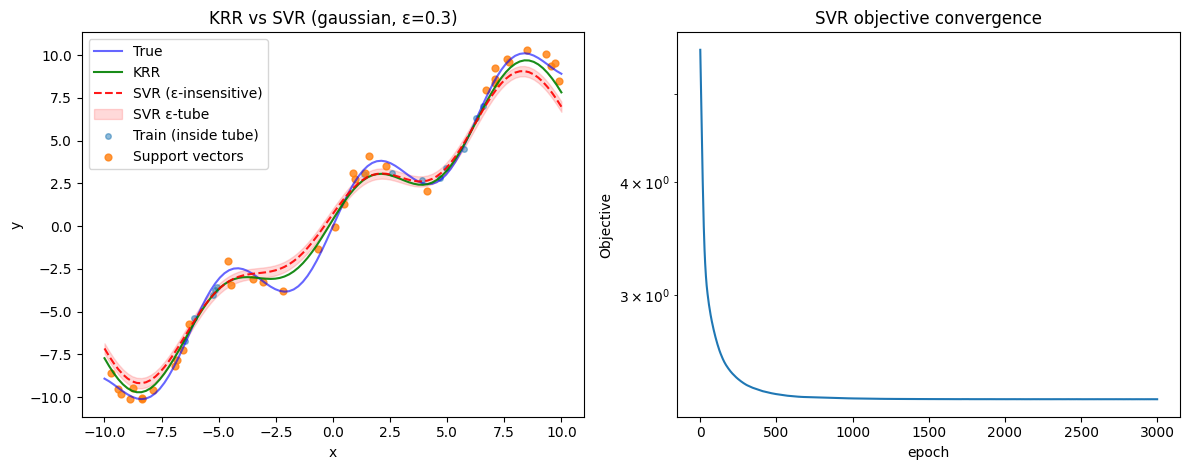

[uniform, scale=0.4]  KRR test MSE = 0.2629 | SVR test MSE = 0.6773 | SVs = 36/50 (72.0%)


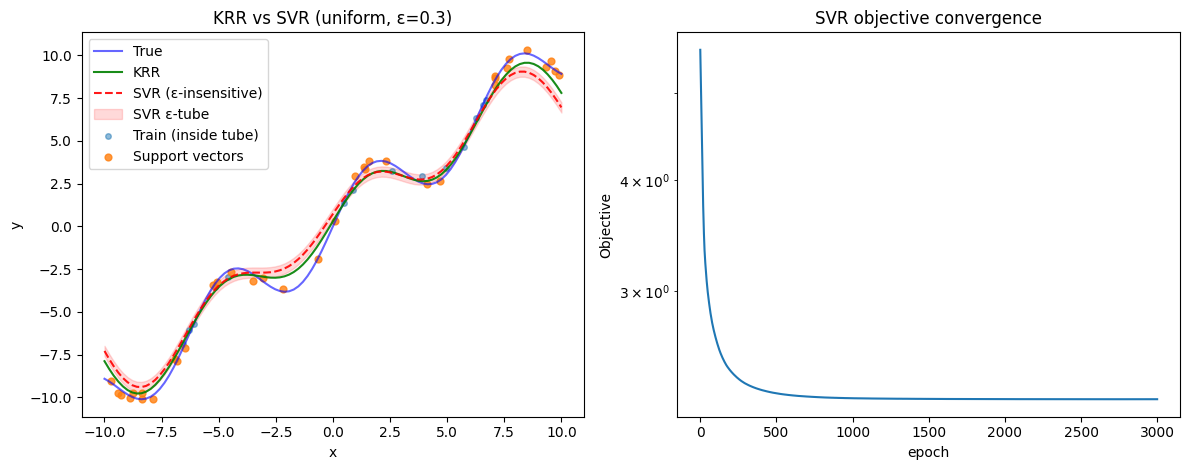

In [39]:
sigma = 2.0
kernel = GaussianKernel(sigma=sigma)

res_gauss = demo_krr_vs_svr(
    X=X, Z=Z, f=f, kernel=kernel,
    lbda_krr=1e-2, lbda_svr=1e-2, eps=0.3,
    noise_type="gaussian", noise_scale=0.4, seed=0, epochs_svr=3000
)

res_unif = demo_krr_vs_svr(
    X=X, Z=Z, f=f, kernel=kernel,
    lbda_krr=1e-2, lbda_svr=1e-2, eps=0.3,
    noise_type="uniform", noise_scale=0.4, seed=1, epochs_svr=3000
)

> **Question 5:** 
>
> What happens with the Support Vector fraction when $\varepsilon$ increases?

When $\epsilon$ increases, the SVR’s $\epsilon$ insensitive tube becomes wider. This means more training points fall inside the tube and are not penalized, so fewer of them become support vectors. In short, as $\epsilon$ gets larger, the fraction of support vectors decreases, and the model becomes smoother and less sensitive to small variations.



--- ε = 0.1 ---
[gaussian, scale=0.4]  KRR test MSE = 0.2949 | SVR test MSE = 0.588 | SVs = 43/50 (86.0%)


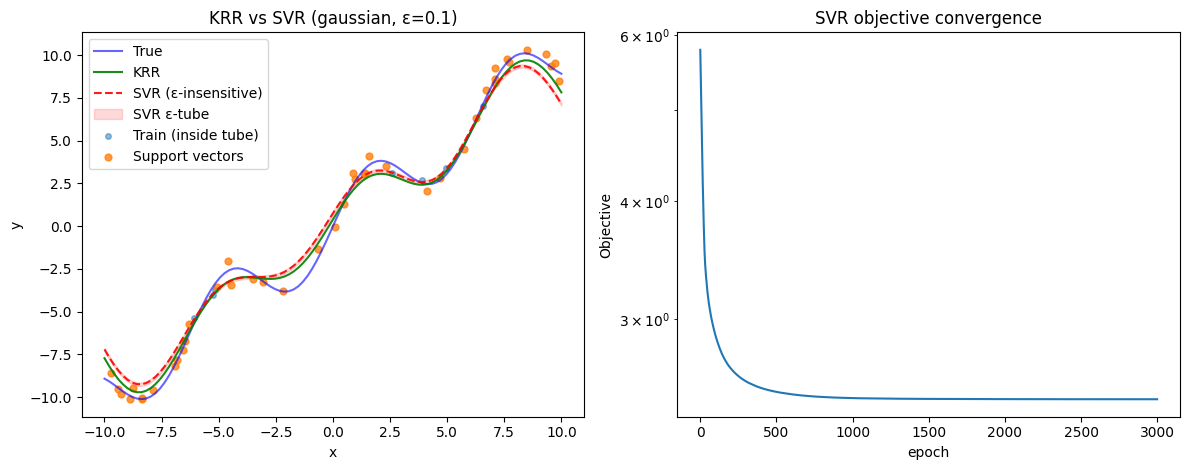

[uniform, scale=0.4]  KRR test MSE = 0.2629 | SVR test MSE = 0.5741 | SVs = 42/50 (84.0%)


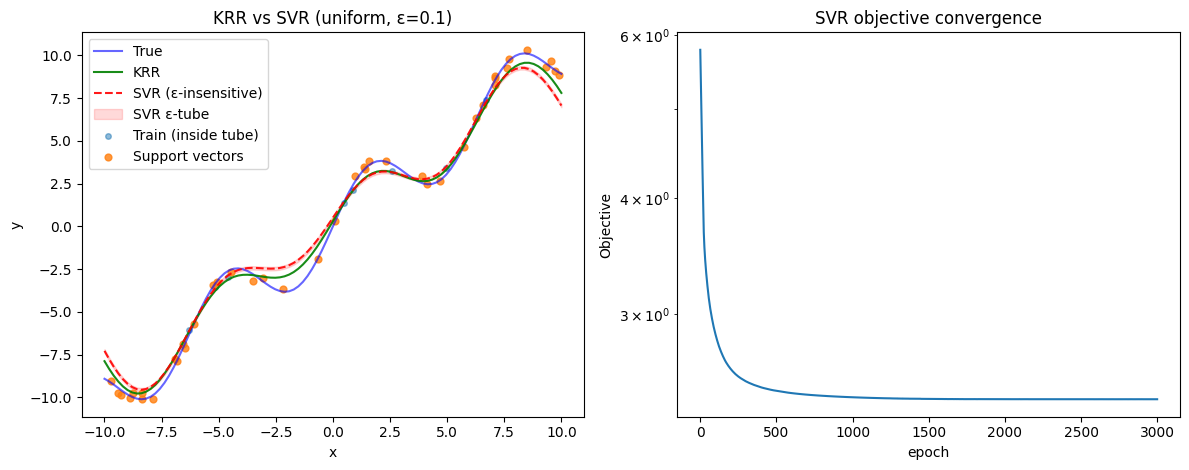


--- ε = 0.3 ---
[gaussian, scale=0.4]  KRR test MSE = 0.2949 | SVR test MSE = 0.771 | SVs = 37/50 (74.0%)


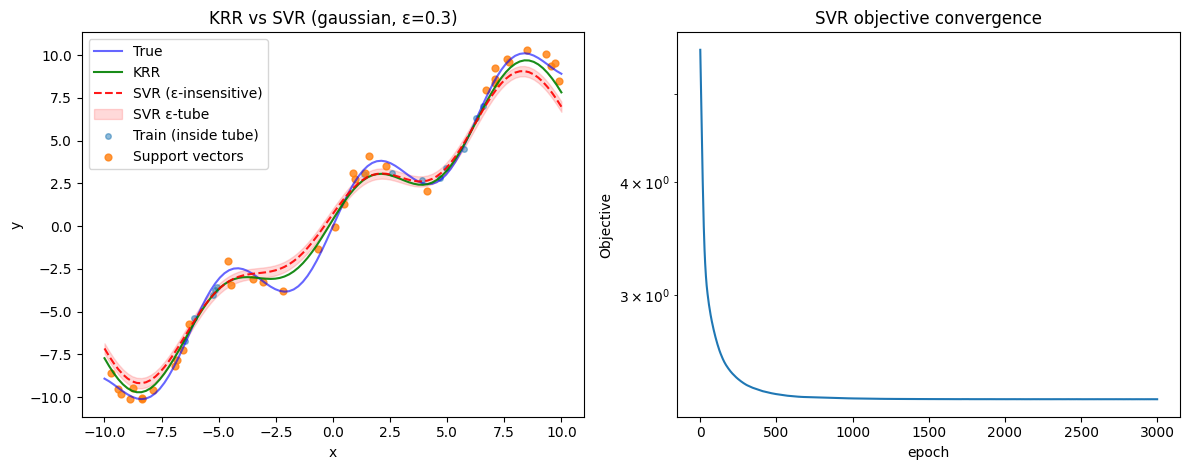

[uniform, scale=0.4]  KRR test MSE = 0.2629 | SVR test MSE = 0.6773 | SVs = 36/50 (72.0%)


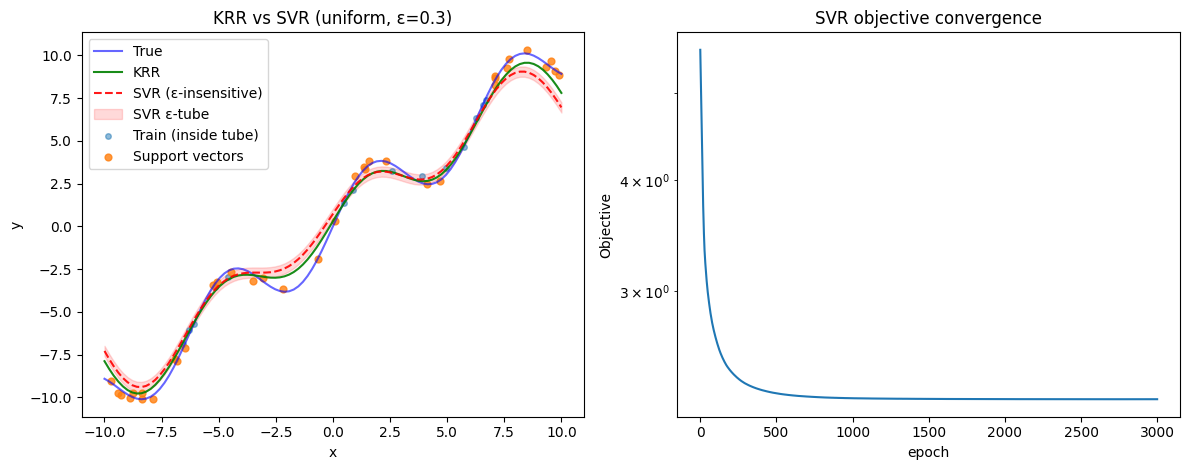


--- ε = 0.5 ---
[gaussian, scale=0.4]  KRR test MSE = 0.2949 | SVR test MSE = 0.9755 | SVs = 32/50 (64.0%)


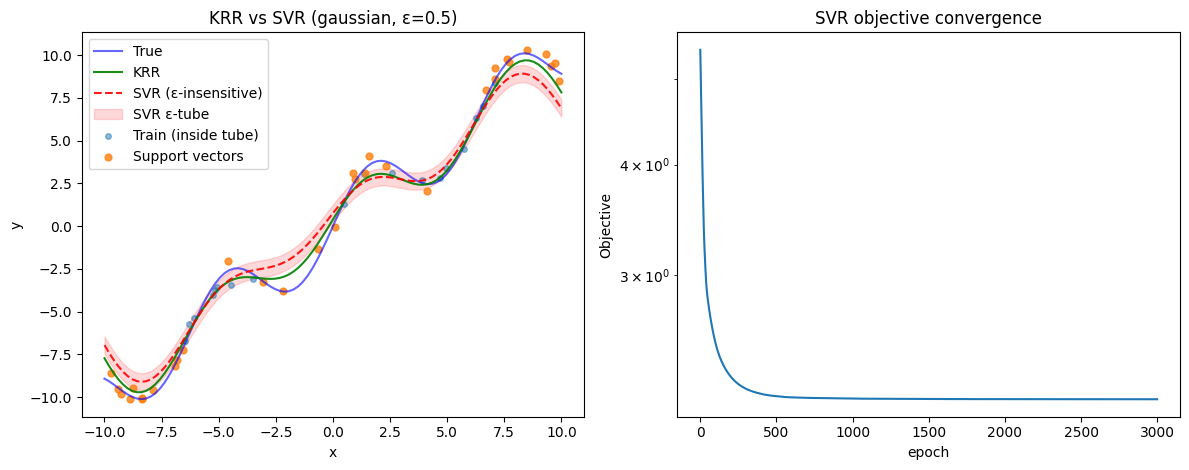

[uniform, scale=0.4]  KRR test MSE = 0.2629 | SVR test MSE = 0.9595 | SVs = 33/50 (66.0%)


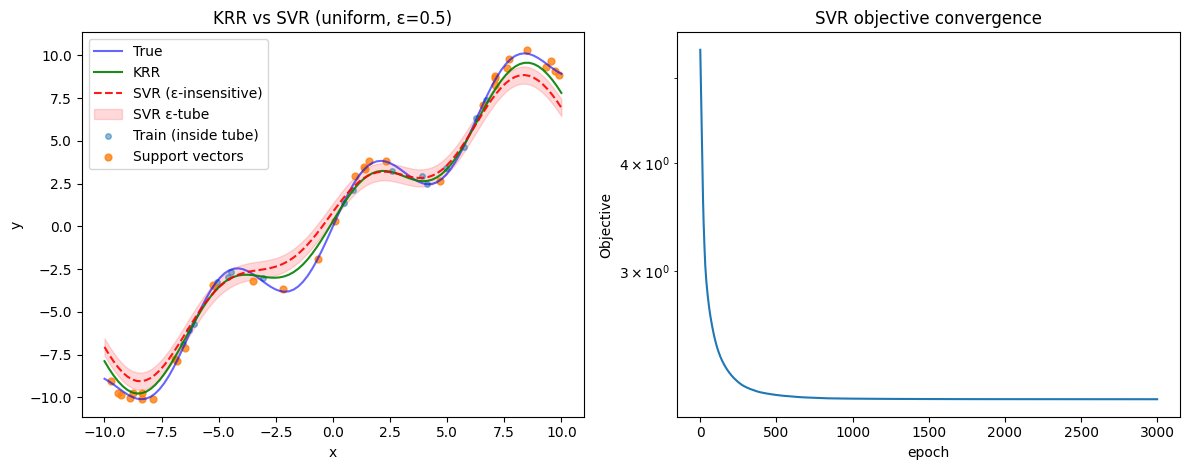

In [40]:
sigma = 2.0
kernel = GaussianKernel(sigma=sigma)

eps = [0.1, 0.3, 0.5]
for e in eps:
    print(f"\n--- ε = {e} ---")
    res_gauss = demo_krr_vs_svr(
        X=X, Z=Z, f=f, kernel=kernel,
        lbda_krr=1e-2, lbda_svr=1e-2, eps=e,
        noise_type="gaussian", noise_scale=0.4, seed=0, epochs_svr=3000
    )

    res_unif = demo_krr_vs_svr(
        X=X, Z=Z, f=f, kernel=kernel,
        lbda_krr=1e-2, lbda_svr=1e-2, eps=e,
        noise_type="uniform", noise_scale=0.4, seed=1, epochs_svr=3000
    )

> **Question 6:** 
>
> Solve SVR for different values of ε (e.g. 0.1, 0.3, 0.5) and test MSE. What do you observe? Explain why this happens.   

From the experiments, we can observe the following results:

As the parameter **ε** increases, two clear trends appear.
First, the **test MSE increases** for both the Gaussian and uniform kernels.
Second, the **fraction of support vectors decreases** , from around 85% at ε = 0.1 to about 65% at ε = 0.5.

This behavior aligns with the theoretical role of ε in SVR. A small ε defines a narrow ε-insensitive tube around the regression function, meaning that even small deviations are penalized. As a result, most training points lie outside the tube and become support vectors. The model therefore tries to fit nearly all points closely, which can lead to overfitting or sensitivity to noise. This explains the relatively lower MSE for ε = 0.1 but also the large number of support vectors.

When ε increases to 0.3 or 0.5, the tube widens, allowing small residuals to be ignored. Fewer data points now contribute to the optimization, and the model becomes smoother and less flexible. However, this comes at the cost of a higher test MSE, as the model begins to underfit and loses fine details of the target function.


# III. Quantile Regression: Going beyond the mean (Bonus)

Quantile level $\tau \in (0,1)$ with pinball loss $\rho_\tau(u)$,
\begin{equation*}
\rho_\tau(u)
= u\bigl(\tau-\mathbf{1}\{u<0\}\bigr)
= \begin{cases}
\tau\,u, & u \ge 0,\\[4pt]
(\tau-1)\,u, & u < 0.
\end{cases}
\end{equation*}

Linear model (no intercept):
\begin{equation*}
\min_{w\in\mathbb{R}^d} \;\frac{1}{n}\sum_{i=1}^n \rho_\tau\!\big(y_i - \langle w,x_i\rangle\big) \;+\; \lambda \|w\|_2^2.
\end{equation*}

Kernel (RKHS) model (no intercept):
\begin{equation*}
\min_{f\in\mathcal{H}} \;\frac{1}{n}\sum_{i=1}^n \rho_\tau\!\big(y_i - f(x_i)\big) \;+\; \lambda \|f\|_{\mathcal{H}}^2.
\end{equation*}

Representer form:
\begin{equation*}
f(\cdot)=\sum_{i=1}^n \alpha_i\,k(x_i,\cdot),\qquad K_{ij}=k(x_i,x_j).
\end{equation*}

Finite-dimensional problem:
\begin{equation*}
\min_{\alpha\in\mathbb{R}^n} \;\frac{1}{n}\sum_{i=1}^n \rho_\tau\!\big(y_i - (K\alpha)_i\big) \;+\; \lambda\,\alpha^\top K \alpha.
\end{equation*}

Predictor:
\begin{equation*}
\hat{f}_\tau(x)=\sum_{i=1}^n \alpha_i^\star\,k(x_i,x).
\end{equation*}

Subgradient optimality:
\begin{equation*}
0 \in -\frac{1}{n}K\,s + 2\lambda K\alpha,
\end{equation*}

\begin{equation*}
s_i \in \partial \rho_\tau\!\big(y_i-(K\alpha)_i\big)=
\begin{cases}
\{\tau-1\}, & y_i-(K\alpha)_i<0,\\
[\tau-1,\;\tau], & =0,\\
\{\tau\}, & >0.
\end{cases}
\end{equation*}

> **Question Bonus:** 
>
> Implement Kernel Quantile Regression (KQR) and plot KQR for $\tau=[0.1, 0.5, 0.9]$. Compare the results with ridge regression. 

In [41]:
def fit_quantile_regression(
    Kxx: np.ndarray,
    y: np.ndarray,
    tau: float = 0.5,
    lbda: float = 1e-2,
    lr_alpha: float = 1e-2,
    lr_b: float = 1e-3,
    epochs: int = 3000,
    seed: int = 0,
) -> Tuple[np.ndarray, float, list]:
    """
    Full-batch gradient descent for Kernel Quantile Regression (KQR).
    
    Objective:
        J(α, b) = (1/n) ∑ ρ_τ(y_i - (Kα)_i - b) + λ αᵀKα
    where:
        ρ_τ(r) = r (τ - 1_{r < 0})   (pinball loss)
    
    Args:
        Kxx:  (n, n) kernel Gram matrix for training samples
        y:    (n,) target vector
        tau:  quantile level ∈ (0, 1)
        lbda: regularization parameter λ
        lr_alpha, lr_b: learning rates
        epochs: number of gradient descent steps
        seed: random seed (for reproducibility)
    
    Returns:
        α (n,), b (float), history (list of objective values)
    """
    rng = np.random.default_rng(seed)
    n = Kxx.shape[0]
    alpha = np.zeros(n)
    b = 0.0
    history = []

    def objective(a: np.ndarray, b_: float) -> float:
        r = y - (Kxx @ a + b_)
        loss = r * (tau - (r < 0).astype(float))
        return float(np.mean(loss) + lbda * a @ (Kxx @ a))

    for _ in range(epochs):
        Ka = Kxx @ alpha
        r = y - (Ka + b)

        # Subgradient of pinball loss
        dr = np.where(r > 0, tau, tau - 1.0)

        # Gradients
        grad_alpha = -(Kxx @ dr) / n + 2.0 * lbda * (Kxx @ alpha)
        grad_b = -np.mean(dr)

        # Gradient descent updates
        alpha -= lr_alpha * grad_alpha
        b -= lr_b * grad_b

        # Record objective
        history.append(objective(alpha, b))

    return alpha, b, history


def demo_krr_vs_qr(
    X: np.ndarray,
    Z: np.ndarray,
    f,  # callable
    kernel,
    lbda_krr: float = 1e-2,
    lbda_qr: float = 1e-2,
    tau: float = 0.5,
    noise_type: str = "gaussian",
    noise_scale: float = 0.2,
    seed: int = 0,
    epochs_qr: int = 3000,
    lr_alpha: float = 1e-2,
    lr_b: float = 1e-3,
):
    """
    Compare Kernel Ridge Regression (mean regression) and
    Kernel Quantile Regression (KQR) at quantile τ.
    """

    rng = np.random.default_rng(seed)
    y_true = f(X).reshape(-1)

    # Add noise
    if noise_type.lower() == "gaussian":
        noise = rng.normal(0.0, noise_scale, size=len(X))
    elif noise_type.lower() == "uniform":
        noise = rng.uniform(-noise_scale, noise_scale, size=len(X))
    else:
        raise ValueError("noise_type must be 'gaussian' or 'uniform'")
    y_obs = y_true + noise

    # Compute Gram matrices
    Kxx = kernel.get_Kxx(X)
    Kxz = kernel.get_Kxz(X, Z)
    Kxx_c = center_train_gram_matrix(Kxx)
    Kxz_c = center_test_gram_matrix(Kxx, Kxz)

    # -------- KRR --------
    alpha_krr = get_alpha_KRR(Kxx_c, y_obs, lbda_krr)
    y_pred_Z_krr = kernel.compute_prediction_test(Kxz_c, alpha_krr).reshape(-1)

    # -------- KQR --------
    alpha_qr, b_qr, hist = fit_quantile_regression(
        Kxx_c, y_obs, tau=tau, lbda=lbda_qr,
        lr_alpha=lr_alpha, lr_b=lr_b,
        epochs=epochs_qr, seed=seed
    )
    y_pred_Z_qr = (kernel.compute_prediction_test(Kxz_c, alpha_qr) + b_qr).reshape(-1)

    # -------- Evaluate --------
    y_true_Z = f(Z).reshape(-1)
    mse_krr = float(np.mean((y_true_Z - y_pred_Z_krr)**2))
    mse_qr = float(np.mean((y_true_Z - y_pred_Z_qr)**2))

    print(f"[{noise_type}, scale={noise_scale}]  "
          f"KRR test MSE = {mse_krr:.4f} | "
          f"KQR (τ={tau}) test MSE = {mse_qr:.4f}")

    # -------- Plot --------
    plt.figure(figsize=(12, 4.8))

    # (1) Regression curves
    plt.subplot(1, 2, 1)
    plt.title(f"KRR vs Kernel Quantile Regression (τ={tau})")
    plt.plot(Z, y_true_Z, 'b', label='True Function', alpha=0.7)
    plt.plot(Z, y_pred_Z_krr, 'g', label='KRR (mean)', alpha=0.9)
    plt.plot(Z, y_pred_Z_qr, 'orange', linestyle='--', label=f'KQR τ={tau}', alpha=0.9)
    plt.scatter(X, y_obs, s=20, alpha=0.5, label='Training Data')
    plt.xlabel("x"); plt.ylabel("y"); plt.legend()

    # (2) Objective convergence
    plt.subplot(1, 2, 2)
    plt.title("KQR Objective Convergence")
    plt.plot(hist)
    plt.yscale('log')
    plt.xlabel("Epoch"); plt.ylabel("Objective (log scale)")
    plt.tight_layout()
    plt.show()

    return {
        "alpha_krr": alpha_krr,
        "alpha_qr": alpha_qr,
        "b_qr": b_qr,
        "mse_krr": mse_krr,
        "mse_qr": mse_qr,
        "history_qr": hist,
    }



--- τ = 0.1 ---
[gaussian, scale=0.4]  KRR test MSE = 0.2949 | QR (τ=0.1) test MSE = 22.91


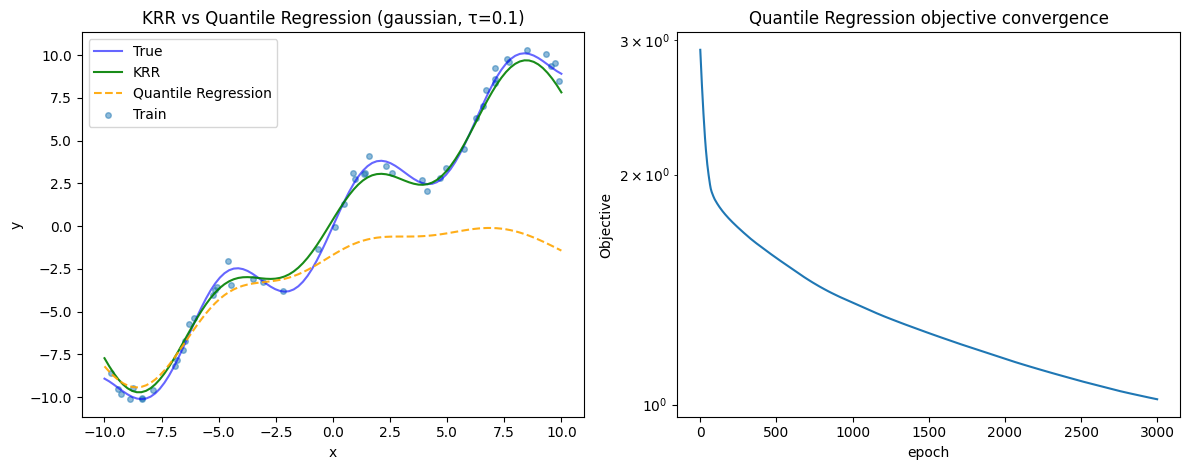

[uniform, scale=0.4]  KRR test MSE = 0.2629 | QR (τ=0.1) test MSE = 22.93


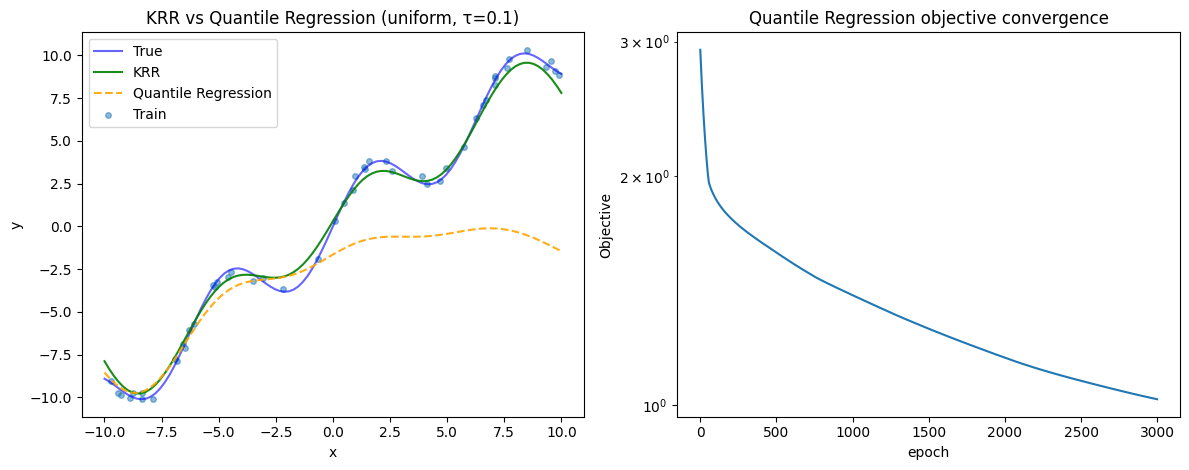


--- τ = 0.5 ---
[gaussian, scale=0.4]  KRR test MSE = 0.2949 | QR (τ=0.5) test MSE = 7.176


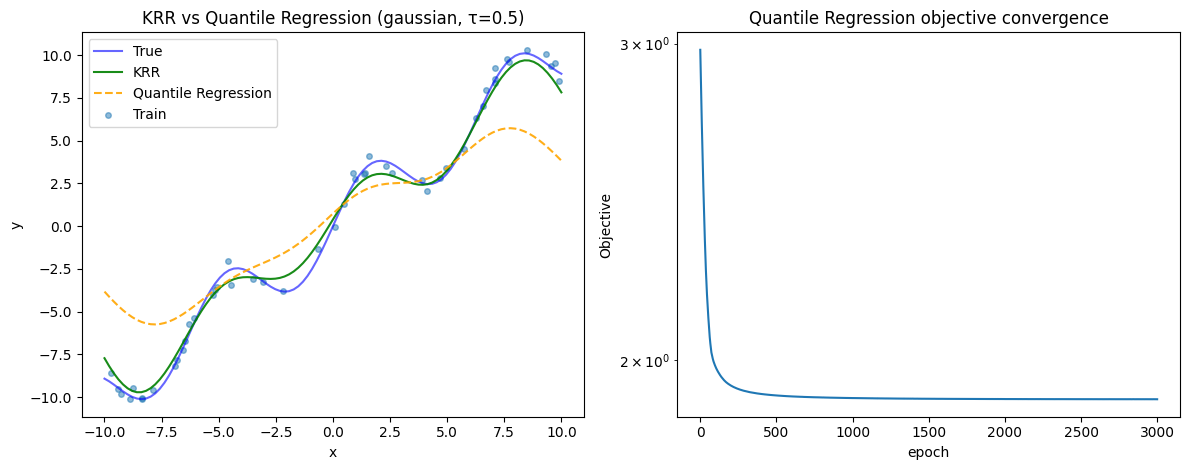

[uniform, scale=0.4]  KRR test MSE = 0.2629 | QR (τ=0.5) test MSE = 7.468


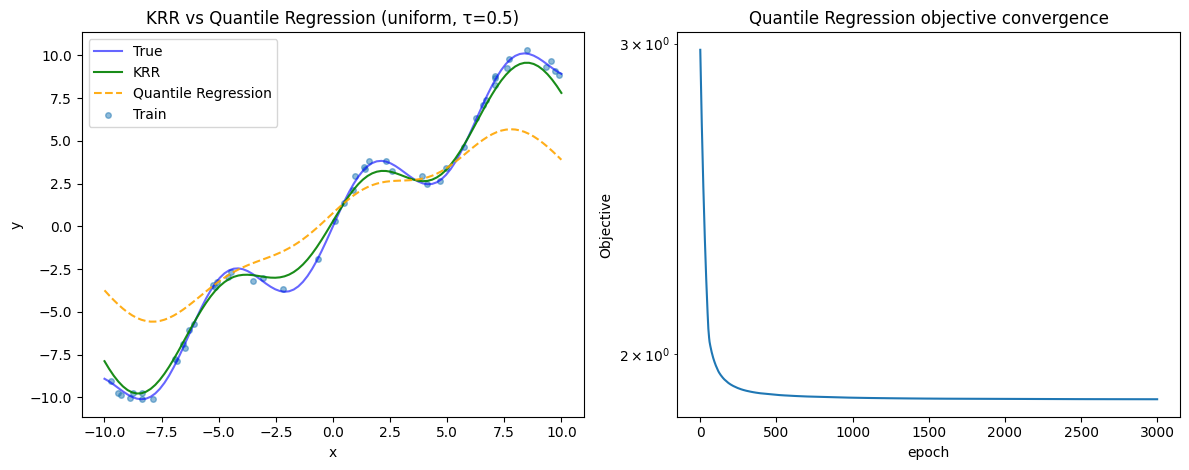


--- τ = 0.9 ---
[gaussian, scale=0.4]  KRR test MSE = 0.2949 | QR (τ=0.9) test MSE = 25.93


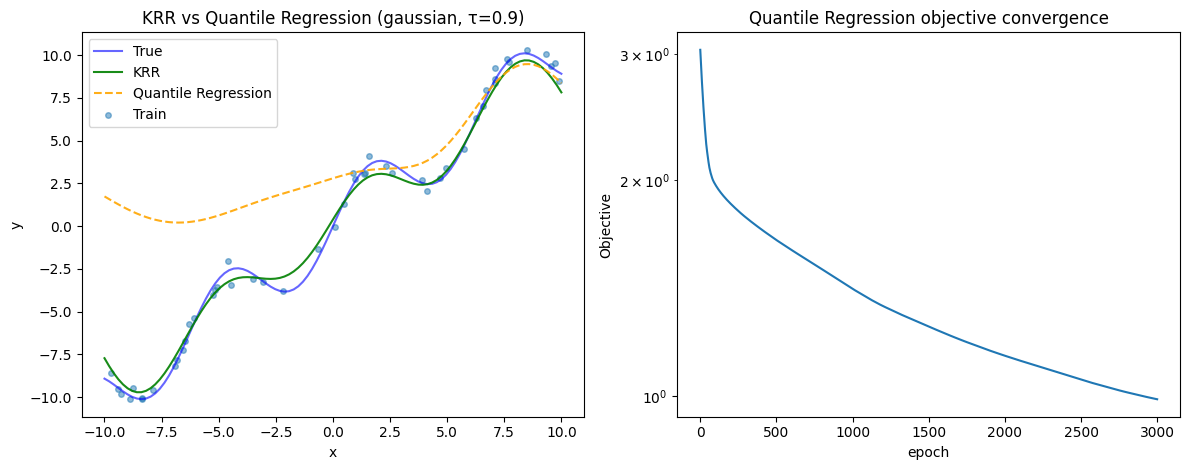

[uniform, scale=0.4]  KRR test MSE = 0.2629 | QR (τ=0.9) test MSE = 25.83


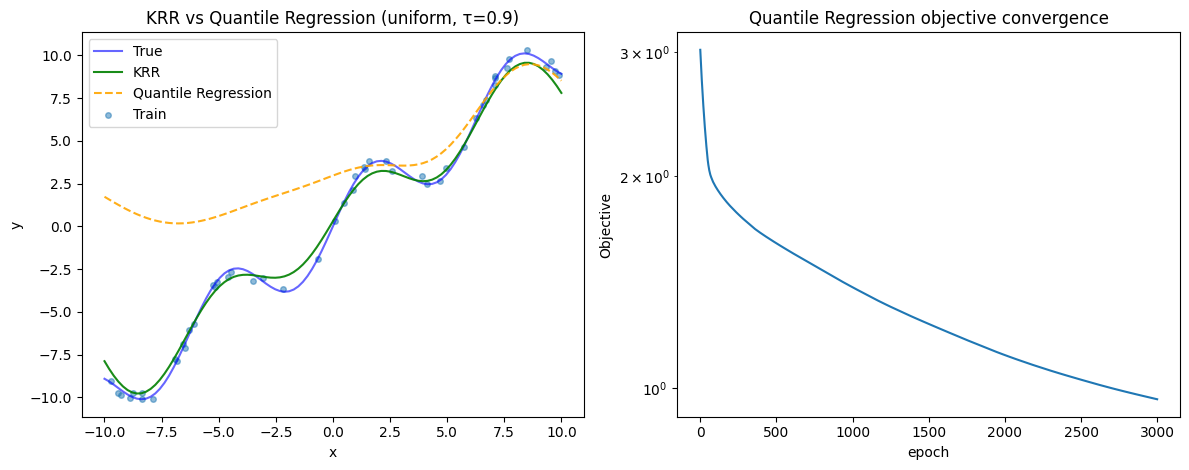

In [45]:

sigma = 2.0
kernel = GaussianKernel(sigma=sigma)
taus = [0.1,0.5, 0.9]
for tau in taus:
    print(f"\n--- τ = {tau} ---")
    res_gauss = demo_krr_vs_qr(
        X=X, Z=Z, f=f, kernel=kernel,
        lbda_krr=1e-2, lbda_qr=1e-2, tau=tau,
        noise_type="gaussian", noise_scale=0.4, seed=0, epochs_qr=3000
    )

    res_unif = demo_krr_vs_qr(
        X=X, Z=Z, f=f, kernel=kernel,
        lbda_krr=1e-2, lbda_qr=1e-2, tau=tau,
        noise_type="uniform", noise_scale=0.4, seed=1, epochs_qr=3000
    )

I observe that when **τ = 0.1**, the model focuses on the **lower part of the data**, fitting points where ( y ) values are smaller (mostly for ( x < 0 )).
When **τ = 0.5**, the model fits the **central trend** of the data, corresponding to the median around ( x = 0 ).
Finally, when **τ = 0.9**, the model follows the **upper region of the data**, capturing higher ( y ) values (mostly for ( x > 0 )).

In summary, as τ increases, the regression curve shifts upward, moving from the lower quantile (τ = 0.1) to the median (τ = 0.5) and then to the upper quantile (τ = 0.9).
